# Session 5: CNN on MNIST and YOLOv8

This notebook contains structured tasks for building a CNN on MNIST and experimenting with Ultralytics YOLOv8 (pretrained inference and a short training example).

**Instructions:**
- Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- Use `%matplotlib inline` for visualizations.
- If you need to install packages (e.g., `ultralytics`), use `%pip` in a cell.
- When using external datasets, do NOT upload them to GitHub.

### ***DO NOT UPLOAD LARGE DATASETS OR MODEL WEIGHTS TO GITHUB***
<hr>

## Task 1: Convolutional Neural Network on MNIST — Build, Train, Evaluate, Visualize
Train a simple CNN on the MNIST handwritten digits dataset. After training, generate predictions on the test set, compare them to ground truth labels, and visualize a few results.

**Why this matters:**
- MNIST is a classic entry point for image classification and CNNs.
- You will practice the full workflow: data loading, model definition, training, evaluation, and visualization.

**Steps:**
- Load MNIST with appropriate transforms (normalize).
- Define a small CNN (Conv → ReLU → Pool → FC).
- Train for a few epochs (2–3 for demo).
- Evaluate on the test set and compute accuracy.
- Visualize several test images with predicted and true labels.

**Hint:** Use `torchvision.datasets.MNIST`, `DataLoader`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.CrossEntropyLoss`.

Using device: cpu


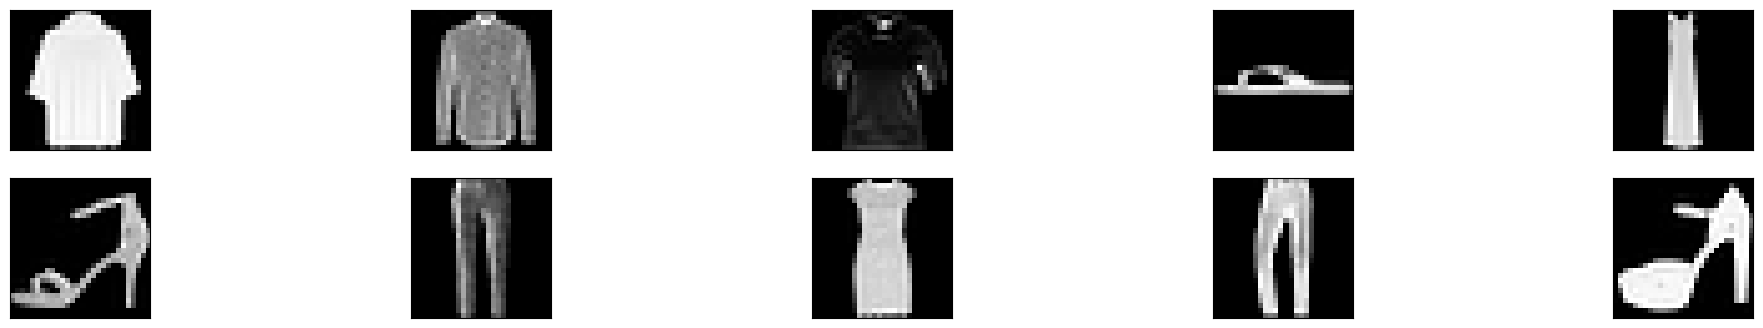

In [37]:
# TODO: Setup environment and imports
# - Import torch, torchvision, numpy, matplotlib
 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
# data loading and transforming
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision import transforms
 
# - Set random seeds and select device (cpu/cuda)
torch.manual_seed(30)
np.random.seed(30)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
cuda = torch.device("cuda")
torch.randn(3)
torch.manual_seed(10)
 
# - Enable %matplotlib inline if needed
 # obtain one batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
images = images.numpy()

# plot the images in the batch, along with the corresponding labels
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(batch_size):
    ax = fig.add_subplot(2, batch_size//2, idx+1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(images[idx]), cmap='gray')
   
 


In [38]:
# TODO: Load MNIST train/test datasets and create DataLoaders
# - Apply ToTensor and Normalize transforms
# - Create train_loader and test_loader
data_transform = transforms.ToTensor()

 
train_data = FashionMNIST(root='./data', train=True,
                                   download=True, transform=data_transform)

test_data = FashionMNIST(root='./data', train=False,
                                  download=True, transform=data_transform)

print('Train data, number of images: ', len(train_data))
print('Test data, number of images: ', len(test_data))
batch_size = 10

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)


Train data, number of images:  60000
Test data, number of images:  10000


In [ ]:
# TODO: Define a small CNN suitable for MNIST (1x28x28 input)
# - Use Conv2d, ReLU, MaxPool2d, Linear layers
# - Return logits for 10 classes
class MNIST_CNN(nn.Module):
    def __init__(self):
        super(MNIST_CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, 1)    
        self.conv2 = nn.Conv2d(16, 32, 3, 1)   
        self.pool = nn.MaxPool2d(2, 2)         
        self.fc1 = nn.Linear(32*12*12, 128)
        self.fc2 = nn.Linear(128, 10)          

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MNIST_CNN().to(device)
print(model)

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4608, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [ ]:
# TODO: Set up optimizer and loss function
# - Choose Adam/SGD and CrossEntropyLoss
# TODO: Implement a short training loop (2–3 epochs)
# - Print loss/accuracy per epoch
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        


NameError: name 'output' is not defined

In [ ]:
# TODO: Evaluate on the test set and compute accuracy
# - Switch model to eval mode
# - Accumulate correct predictions and total

In [ ]:
# TODO: Visualize a few test images with predicted and true labels
# - Sample a batch from test_loader
# - Run model and plot images with 'pred vs true' titles

## Task 2: YOLOv8 Pretrained Predictions (No Training)
Use a pretrained YOLOv8 model to run inference on any image of your choice and visualize detections.

**Why this matters:**
- Demonstrates transfer learning and using pretrained models for object detection.
- Learn how to quickly test a detector on real images.

**Steps:**
- Install `ultralytics` if not available.
- Load a YOLOv8 model (e.g., `yolov8n.pt`).
- Run predictions on an image path.
- Visualize the detections (boxes, labels, confidences).

**Hint:** Use `from ultralytics import YOLO`, `YOLO('yolov8n.pt')`, and `model.predict(source=...)`.

In [7]:
# TODO: Install ultralytics if needed (pip)
# %pip install ultralytics
# - Restart the kernel if required after installation
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\dARINE\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



Found https://ultralytics.com/images/zidane.jpg locally at zidane.jpg
image 1/1 c:\Task4\zidane.jpg: 384x640 2 persons, 1 tie, 30.2ms
Speed: 1.1ms preprocess, 30.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


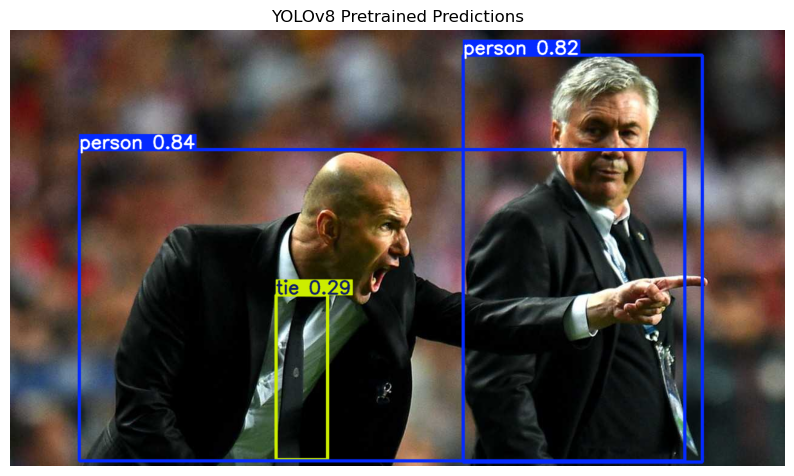

In [22]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import cv2
# TODO: Load a pretrained YOLOv8 model and run predictions on an image
model = YOLO('yolov8n.pt')
 
image_path = 'https://ultralytics.com/images/zidane.jpg'

results = model.predict(source=image_path, save=False)

# - Visualize results with matplotlib (convert BGR->RGB if using OpenCV)
annotated_frame = results[0].plot()   
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)   
plt.figure(figsize=(10, 6))
plt.imshow(annotated_frame)
plt.axis('off')
plt.title("YOLOv8 Pretrained Predictions")
plt.show()

## Task 3: YOLOv8 Training Example (Small Demo)
Choose any small dataset (e.g., from Roboflow or Kaggle) and train a YOLOv8 model for a few epochs (e.g., 3) as a demonstration. Then run predictions with the trained model.

**Why this matters:**
- Understand the end-to-end YOLO training pipeline.
- See how dataset configuration (classes, paths) connects to training code.

**Steps:**
- Prepare your dataset directory and a `data.yaml` describing train/val paths and class names.
- Train a small model (e.g., `yolov8n.pt`) for ~3 epochs.
- Run predictions on a few sample images.
- Reflect: Are the predictions what you expected? Why or why not?

**Notes:**
- Do NOT upload datasets to GitHub. Keep them locally or use a data hosting service.
- Training for 3 epochs is just for demonstration; try longer training later.
- If you can't use GPU, small images and fewer epochs help.
- If you can't use GPU, you can train your models on Kaggle or Google Colab in the future for free access to GPUs on their servers

In [3]:
# TODO: Provide path to your YOLOv8 data.yaml
# - Ensure train/val image directories and class names are correct
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt 
model = YOLO('yolov8n.pt')

 

In [27]:
# TODO: Train YOLOv8 for a few epochs (e.g., 3)
# - Save the path to best weights (runs/detect/train*/weights/best.pt)
model = YOLO('yolov8n.pt')
data_yaml = 'coco128.yaml' 
results = model.train(data=data_yaml, epochs=3, imgsz=320)

import glob, os

# Automatically find the latest trained model
weight_paths = sorted(glob.glob('runs/**/weights/best.pt', recursive=True), key=os.path.getmtime)
if weight_paths:
    best_weight = weight_paths[-1]
    print(f"✅ Using trained weights from: {best_weight}")
    trained_model = YOLO(best_weight)
else:
    raise FileNotFoundError("No best.pt file found under runs/. Check your training logs.")

Ultralytics 8.3.205  Python-3.13.5 torch-2.8.0+cpu CPU (AMD Ryzen AI 9 HX 370 w/ Radeon 890M)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train11, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

In [26]:
# TODO: Run predictions with the trained YOLO model and visualize
# - Pick one or more images and display bounding boxes/labels
sample_image = 'https://ultralytics.com/images/bus.jpg'

pred_results = trained_model.predict(source=sample_image, conf=0.5, save=True)

# Step 5: Visualize one of the prediction results
annotated_frame = pred_results[0].plot()                   # Get first prediction
annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)  # Convert for matplotlib

plt.figure(figsize=(10, 6))
plt.imshow(annotated_frame)
plt.axis('off')
plt.title("YOLOv8 Custom Model Predictions")
plt.show()



Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
WARNING Image Read Error c:\Task4\bus.jpg


ValueError: need at least one array to stack

### Reflection
- Are the predictions what you expected?
- If performance is weak, why? (data size/quality, epochs, augmentations, etc.)
- What would you adjust for a more serious training run?
- What other arguments can you use for the training function.